Saving German_Credit_Data.csv to German_Credit_Data (1).csv
Logistic Regression Accuracy: 71.00%
SVM Accuracy: 75.00%
Naïve Bayes Accuracy: 66.00%


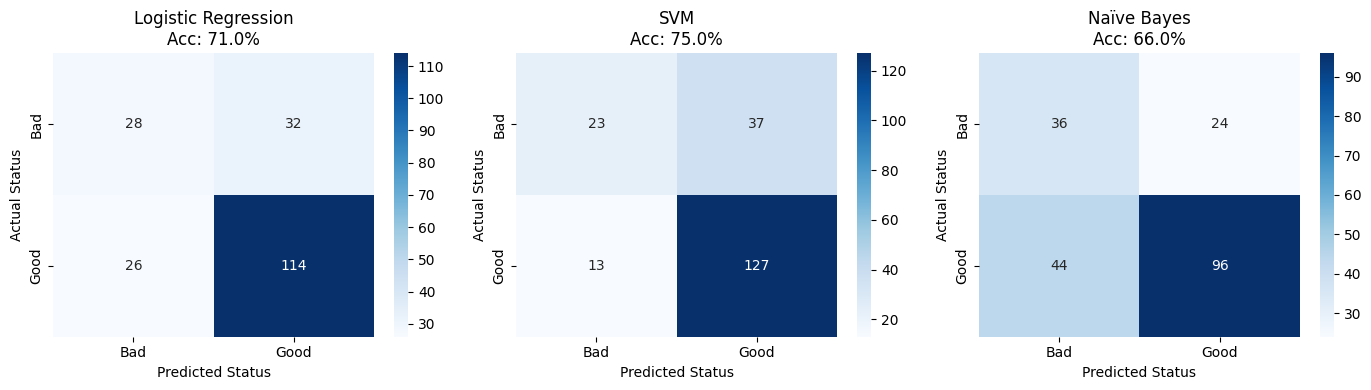

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

if y.dtype == "object":
    y = LabelEncoder().fit_transform(y)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="rbf"),
    "Naïve Bayes": GaussianNB(),
}

plt.figure(figsize=(14, 4))

for idx, (name, model) in enumerate(models.items(), 1):

    if name == "Naïve Bayes":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"{name} Accuracy: {acc * 100:.2f}%")

    plt.subplot(1, 3, idx)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Bad", "Good"],
        yticklabels=["Bad", "Good"],
    )
    plt.title(f"{name}\nAcc: {acc * 100:.1f}%")
    plt.xlabel("Predicted Status")
    plt.ylabel("Actual Status")

plt.tight_layout()
plt.show()